# Fetch landuse segmentation dataset (Sentinel-2 + OSM + Cartofriches)

Builds the training data for `train_unet_landuse.ipynb`: RGB Sentinel-2 tiles paired with
4-class masks (fond / parking / industriel-commercial / friche).

Resumes the segmentation attempt documented (and deliberately halted) in
`docs/roadmap_segmentation.md` — read it first. The first attempt failed because of extreme
class imbalance and too little data (66 tiles, one AOI). This notebook applies the two
priority fixes from that doc's §6:
- multiple distinct AOIs (bassin minier + Calais/Boulogne, see `helpers/landuse_aois.py`)
  instead of a single enlarged one — more tiles, more visual diversity per rare class
- (the second fix, class-weighted loss, lives in `train_unet_landuse.ipynb`)

**This is long-running and network-heavy**: for each AOI it fetches a Sentinel-2 scene
(Planetary Computer STAC), OSM ways (Overpass API) and Cartofriches (Cerema WFS). Expect
several minutes total. Extend `LANDUSE_AOIS` in `helpers/landuse_aois.py` for more tiles.

In [1]:
import sys
import time
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import numpy as np
import planetary_computer
import pystac_client
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds, transform as window_transform
from PIL import Image

from helpers.geo_fetch import fetch_cartofriches_polygons, fetch_osm_polygons
from helpers.image_utils import crop_to_multiple
from helpers.landuse_aois import LANDUSE_AOIS
from helpers.mask_rasterize import CLASS_NAMES, colorize_mask, rasterize_landuse_mask

print(f"{len(LANDUSE_AOIS)} AOIs configured: {[aoi.name for aoi in LANDUSE_AOIS]}")

13 AOIs configured: ['dunkerque', 'lens', 'douai', 'valenciennes', 'bethune', 'calais', 'boulogne_sur_mer', 'le_havre', 'fos_sur_mer', 'maubeuge', 'saint_omer', 'arras', 'annemasse']


### 1/ Configuration

In [2]:
from datetime import date, timedelta

TILE_SIZE = 256  # matches docs/roadmap_segmentation.md's validated tile size
DATE_END = date.today()
DATE_START = DATE_END - timedelta(days=180)
MAX_CLOUD_COVER = 20

DATA_DIR = Path.cwd().parent / "data" / "landuse"
IMAGES_DIR = DATA_DIR / "images"
MASKS_DIR = DATA_DIR / "masks"
MASKS_PREVIEW_DIR = DATA_DIR / "masks_preview"
for d in (IMAGES_DIR, MASKS_DIR, MASKS_PREVIEW_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Tiles -> {IMAGES_DIR} / {MASKS_DIR} (preview: {MASKS_PREVIEW_DIR})")

Tiles -> /Users/erizzolio/Work/Alyra/SOLSCAN/data/landuse/images / /Users/erizzolio/Work/Alyra/SOLSCAN/data/landuse/masks (preview: /Users/erizzolio/Work/Alyra/SOLSCAN/data/landuse/masks_preview)


### 2/ Sentinel-2 fetch helper

Same STAC search as `api/inference.fetch_sentinel2_rgb`, but this one also returns the
window's CRS/transform/shape — needed to rasterize the mask pixel-aligned with the image,
which the API version doesn't need (it's display-only).

In [3]:
def fetch_sentinel2_scene(bbox, date_start: str, date_end: str, max_cloud_cover: float):
    """@return dict with image/crs/transform/shape/cloud_cover/datetime, or None if no scene found."""
    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=planetary_computer.sign_inplace,
    )
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=f"{date_start}/{date_end}",
        query={"eo:cloud_cover": {"lt": max_cloud_cover}},
    )
    items = sorted(search.item_collection(), key=lambda it: it.properties["eo:cloud_cover"])
    if not items:
        return None
    item = items[0]

    with rasterio.open(item.assets["B04"].href) as src:
        scene_crs = src.crs
        bounds = transform_bounds("EPSG:4326", scene_crs, *bbox)
        window = from_bounds(*bounds, transform=src.transform)
        win_transform = window_transform(window, src.transform)

    arrays = []
    for band in ("B04", "B03", "B02"):
        with rasterio.open(item.assets[band].href) as src:
            arrays.append(src.read(1, window=window))

    rgb_raw = np.stack(arrays, axis=-1)
    rgb_uint8 = np.clip(rgb_raw / 3000 * 255, 0, 255).astype(np.uint8)
    image = Image.fromarray(rgb_uint8, mode="RGB")

    return {
        "image": image,
        "crs": scene_crs,
        "transform": win_transform,
        "shape": (arrays[0].shape[0], arrays[0].shape[1]),  # (height, width)
        "cloud_cover": item.properties.get("eo:cloud_cover"),
        "datetime": item.properties.get("datetime"),
    }

### 3/ Main loop: fetch + rasterize + tile, per AOI

Each AOI is wrapped in a `try/except` so one failure (no scene, network hiccup) doesn't
abort the whole run. A short sleep between AOIs keeps Overpass's public instance happy.

In [4]:
tile_stats = []  # one dict per AOI, for the summary below

for aoi in LANDUSE_AOIS:
    print(f"\n=== {aoi.name} (bbox={aoi.bbox}) ===")
    try:
        scene = fetch_sentinel2_scene(aoi.bbox, str(DATE_START), str(DATE_END), MAX_CLOUD_COVER)
        if scene is None:
            print(f"[{aoi.name}] no Sentinel-2 scene found, skipping")
            continue
        print(f"[{aoi.name}] scene {scene['datetime']}, cloud cover {scene['cloud_cover']:.1f}%")

        osm = fetch_osm_polygons(aoi.bbox)
        print(f"[{aoi.name}] OSM: {len(osm['parking'])} parking way(s), {len(osm['industrial'])} industrial/commercial way(s)")
        time.sleep(2)  # be nice to the public Overpass instance

        friches = fetch_cartofriches_polygons(aoi.dept_insee_prefix, aoi.bbox)
        print(f"[{aoi.name}] Cartofriches: {len(friches)} friche(s) in AOI")

        mask = rasterize_landuse_mask(
            scene["crs"], scene["transform"], scene["shape"],
            osm_parking=osm["parking"], osm_industrial=osm["industrial"], cartofriches_friches=friches,
        )
        class_ids, class_counts = np.unique(mask, return_counts=True)
        pixel_counts = {CLASS_NAMES[c]: int(n) for c, n in zip(class_ids, class_counts)}
        print(f"[{aoi.name}] mask pixel counts: {pixel_counts}")

        image = crop_to_multiple(scene["image"], TILE_SIZE)
        mask_image = crop_to_multiple(Image.fromarray(mask), TILE_SIZE)
        n_cols = image.width // TILE_SIZE
        n_rows = image.height // TILE_SIZE
        if n_rows == 0 or n_cols == 0:
            print(f"[{aoi.name}] AOI too small for a {TILE_SIZE}px tile, skipping")
            continue

        n_tiles = 0
        for row in range(n_rows):
            for col in range(n_cols):
                box = (col * TILE_SIZE, row * TILE_SIZE, (col + 1) * TILE_SIZE, (row + 1) * TILE_SIZE)
                name = f"{aoi.name}_tile_{row}_{col}.png"
                image.crop(box).save(IMAGES_DIR / name)
                tile_mask = mask_image.crop(box)
                tile_mask.save(MASKS_DIR / name)
                colorize_mask(np.array(tile_mask)).save(MASKS_PREVIEW_DIR / name)
                n_tiles += 1

        print(f"[{aoi.name}] saved {n_tiles} tiles ({n_cols}x{n_rows})")
        tile_stats.append({"aoi": aoi.name, "n_tiles": n_tiles, "pixel_counts": pixel_counts})

    except Exception as exc:
        print(f"[{aoi.name}] FAILED: {exc}")

    time.sleep(2)


=== dunkerque (bbox=(2.2268, 50.9343, 2.5267999999999997, 51.1343)) ===


/var/folders/dg/40src0d13rn9ynfgnsktfhf80000gn/T/ipykernel_39615/3325635870.py:27: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arrays.append(src.read(1, window=window))


[dunkerque] scene 2026-05-01T10:46:51.024000Z, cloud cover 0.0%


[dunkerque] OSM: 1428 parking way(s), 221 industrial/commercial way(s)


[dunkerque] Cartofriches: 42 friche(s) in AOI
[dunkerque] mask pixel counts: {'Fond': 4542170, 'Parking': 8805, 'Industriel/commercial': 198138, 'Friche': 8411}


...

/var/folders/dg/40src0d13rn9ynfgnsktfhf80000gn/T/ipykernel_39615/3325635870.py:27: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  arrays.append(src.read(1, window=window))


[annemasse] scene 2026-02-27T10:30:19.024000Z, cloud cover 0.0%


  (https://overpass-api.de/api/interpreter failed: 504 Server Error: Gateway Timeout for url: https://overpass-api.de/api/interpreter -- retrying in 5s)


  (https://overpass.kumi.systems/api/interpreter failed: 504 Server Error: Gateway Timeout for url: https://overpass.kumi.systems/api/interpreter -- retrying in 5s)


[annemasse] FAILED: 504 Server Error: Gateway Timeout for url: https://lz4.overpass-api.de/api/interpreter


### 4/ Summary

In [5]:
total_tiles = sum(s["n_tiles"] for s in tile_stats)
print(f"Total: {total_tiles} tiles across {len(tile_stats)}/{len(LANDUSE_AOIS)} AOIs")
for s in tile_stats:
    print(f"  {s['aoi']}: {s['n_tiles']} tiles")

# Aggregate class pixel counts across all successfully processed AOIs -- same imbalance
# check as docs/roadmap_segmentation.md §5, to see if the multi-AOI fix actually helped.
total_pixel_counts = {name: 0 for name in CLASS_NAMES}
for s in tile_stats:
    for name, count in s["pixel_counts"].items():
        total_pixel_counts[name] += count
total_pixels = sum(total_pixel_counts.values())
print("\nClass balance across the whole dataset:")
for name, count in total_pixel_counts.items():
    pct = 100 * count / total_pixels if total_pixels else 0
    print(f"  {name}: {count} px ({pct:.3f}%)")

Total: 576 tiles across 10/13 AOIs
  dunkerque: 64 tiles
  lens: 64 tiles
  douai: 48 tiles
  valenciennes: 64 tiles
  bethune: 40 tiles
  calais: 64 tiles
  boulogne_sur_mer: 40 tiles
  maubeuge: 64 tiles
  saint_omer: 64 tiles
  arras: 64 tiles

Class balance across the whole dataset:
  Fond: 41469602 px (96.132%)
  Parking: 87351 px (0.202%)
  Industriel/commercial: 1091056 px (2.529%)
  Friche: 490085 px (1.136%)


### 5/ Visual sanity check

A few random tiles with their raw mask and colorized mask, to catch alignment/rasterization bugs before training.

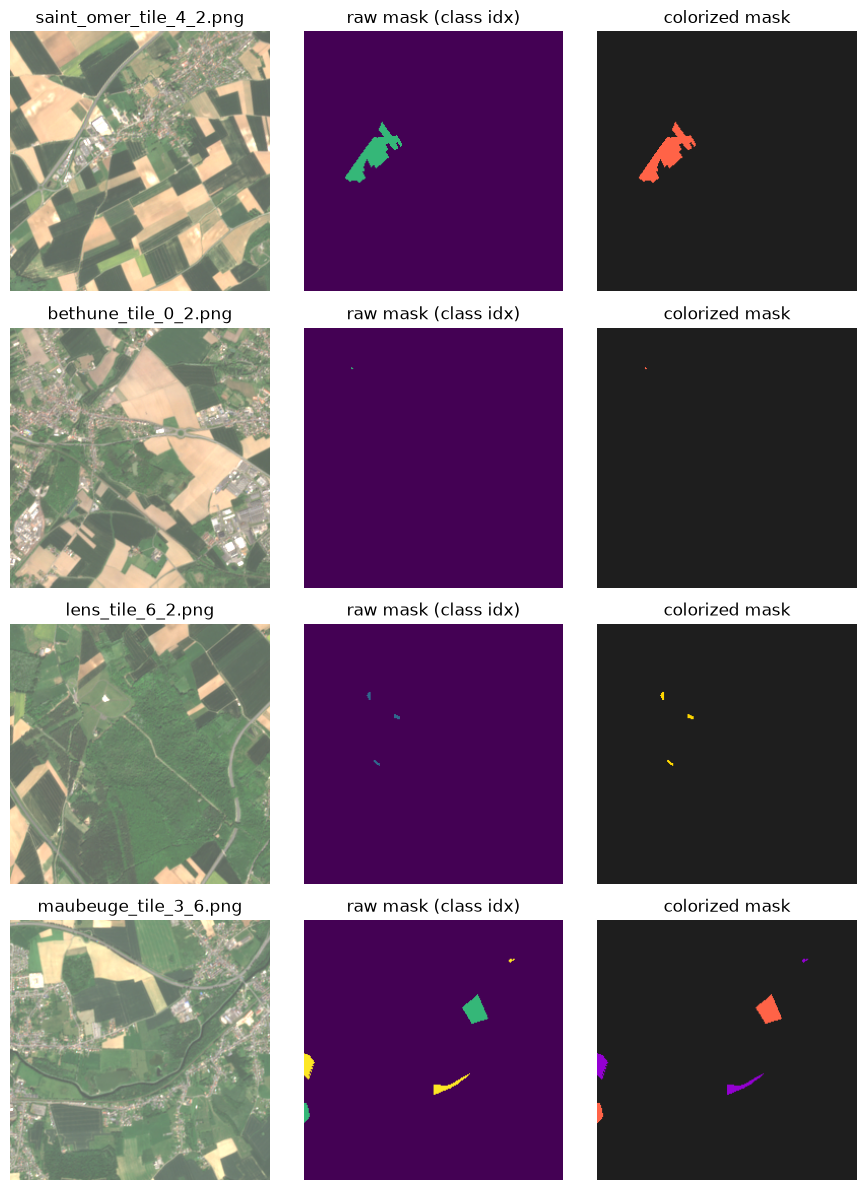

In [6]:
import random

import matplotlib.pyplot as plt

sample_names = random.sample(sorted(p.name for p in IMAGES_DIR.glob("*.png")), k=min(4, total_tiles))

fig, axes = plt.subplots(len(sample_names), 3, figsize=(9, 3 * len(sample_names)))
for i, name in enumerate(sample_names):
    img = Image.open(IMAGES_DIR / name)
    mask_preview = Image.open(MASKS_PREVIEW_DIR / name)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(name)
    axes[i, 1].imshow(np.array(Image.open(MASKS_DIR / name)), vmin=0, vmax=len(CLASS_NAMES) - 1)
    axes[i, 1].set_title("raw mask (class idx)")
    axes[i, 2].imshow(mask_preview)
    axes[i, 2].set_title("colorized mask")
    for ax in axes[i]:
        ax.axis("off")
plt.tight_layout()
plt.show()